Loading CIFAR-10...

Epoch 1/200 - lr=0.01000
  mini-step  200 | processed 25600/50000
--> Epoch 1 done | train_loss=1.9469 | train_acc=0.3551
    Test | test_loss=1.6614 | test_acc=0.4211
    New best test_acc=0.4211 (checkpoint saved)

Epoch 2/200 - lr=0.00970
  mini-step  200 | processed 25600/50000
--> Epoch 2 done | train_loss=1.7440 | train_acc=0.4118
    Test | test_loss=1.6044 | test_acc=0.4484
    New best test_acc=0.4484 (checkpoint saved)

Epoch 3/200 - lr=0.00941
  mini-step  200 | processed 25600/50000
--> Epoch 3 done | train_loss=1.6978 | train_acc=0.4292
    Test | test_loss=1.5592 | test_acc=0.4613
    New best test_acc=0.4613 (checkpoint saved)

Epoch 4/200 - lr=0.00913
  mini-step  200 | processed 25600/50000
--> Epoch 4 done | train_loss=1.6543 | train_acc=0.4435
    Test | test_loss=1.4713 | test_acc=0.4800
    New best test_acc=0.4800 (checkpoint saved)

Epoch 5/200 - lr=0.00885
  mini-step  200 | processed 25600/50000
--> Epoch 5 done | train_loss=1.6265 | train_

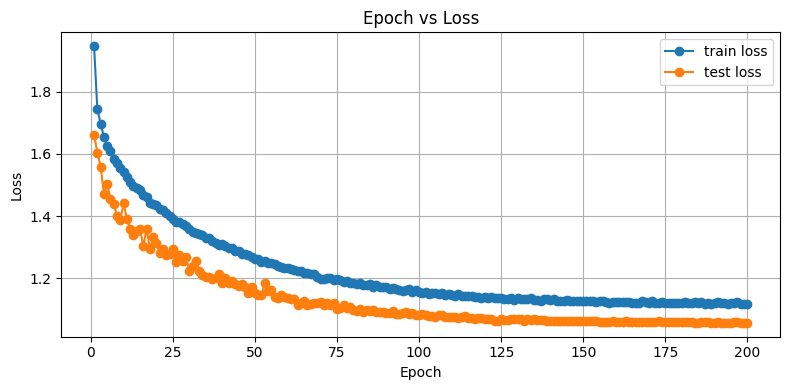

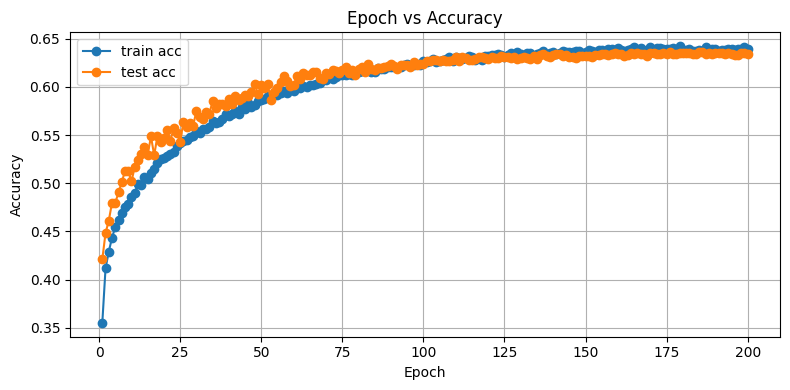

Saved prediction grid to cifar_test_preds.png


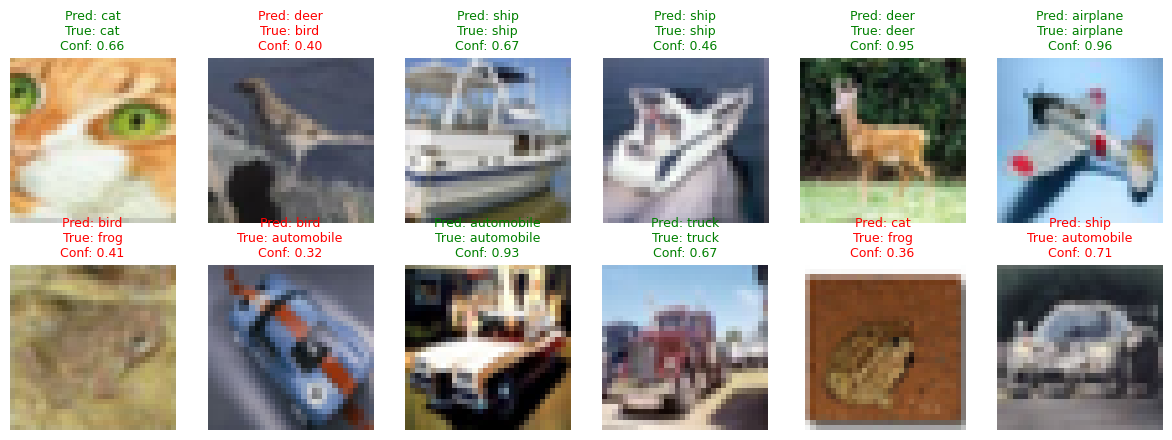

In [ ]:

import os
import pickle
import numpy as np
import time
import matplotlib.pyplot as plt


# 1) CIFAR-10 LOADING HELPERS

CIFAR_DIR = "cifar-10-batches-py"  # folder with data_batch_1..5, test_batch

# Load one CIFAR-10 batch file (returns images as float32 and labels as int64)
def load_cifar10_batch(path):
    with open(path, "rb") as f:
        d = pickle.load(f, encoding="bytes")
    X = d[b"data"].astype(np.float32)
    y = np.array(d[b"labels"], dtype=np.int64)
    return X, y

# Load and concatenate the 5 training batches and also load the test batch
def load_cifar10_dataset(cifar_dir=CIFAR_DIR):
    X_list, y_list = [], []
    for i in range(1, 6):
        Xb, yb = load_cifar10_batch(os.path.join(cifar_dir, f"data_batch_{i}"))
        X_list.append(Xb); y_list.append(yb)
    X_tr = np.vstack(X_list)
    y_tr = np.hstack(y_list)
    X_te, y_te = load_cifar10_batch(os.path.join(cifar_dir, "test_batch"))
    return X_tr, y_tr, X_te, y_te

# Convert integer class labels to one-hot encoded matrix of shape (N, num_classes)
def one_hot(y, num_classes=10, dtype=np.float32):
    oh = np.zeros((y.size, num_classes), dtype=dtype)
    oh[np.arange(y.size), y] = 1.0
    return oh


# 2) Activations / loss

def relu(x): return np.maximum(0.0, x)
def relu_deriv(x): return (x > 0).astype(np.float32)

def softmax(x):
    x_max = np.max(x, axis=1, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_onehot):
    batch = probs.shape[0]
    p = np.clip(probs, 1e-12, 1.0)
    return -np.sum(y_onehot * np.log(p)) / batch


# 3) Data augmentation helpers

# Convert a flattened CIFAR-10 batch (N, 3072) into image tensors (N, 3, 32, 32)

def flat_to_image(batch_flat): return batch_flat.reshape(batch_flat.shape[0], 3, 32, 32)

# Flatten a batch of image tensors (N, 3, 32, 32) back into shape (N, 3072)

def image_to_flat(batch_img): return batch_img.reshape(batch_img.shape[0], -1)

# Apply random 4-pixel padding, random 32×32 crop, and 50% horizontal flip for data augmentation

def random_crop_and_flip(batch_flat, pad=4, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    B = batch_flat.shape[0]
    imgs = flat_to_image(batch_flat)
    H = 32 + 2*pad; W = 32 + 2*pad
    padded = np.zeros((B, 3, H, W), dtype=imgs.dtype)
    padded[:, :, pad:pad+32, pad:pad+32] = imgs
    out = np.empty_like(imgs)
    for i in range(B):
        top = rng.integers(0, 2*pad + 1)
        left = rng.integers(0, 2*pad + 1)
        crop = padded[i, :, top:top+32, left:left+32]
        if rng.random() < 0.5:
            crop = crop[:, :, ::-1]
        out[i] = crop
    return image_to_flat(out)


# 4) Vectorized DNN with SGD+momentum

class DNN:
        # Initialize network weights and momentum buffers (Xavier or small-rand init)
    def __init__(self, layers, seed=0, weight_scale='xavier'):
        self.layers = layers
        rng = np.random.default_rng(seed)
        self.W, self.b = [], []
        for i in range(len(layers)-1):
            in_dim, out_dim = layers[i], layers[i+1]
            if weight_scale == 'xavier':
                limit = np.sqrt(6.0 / (in_dim + out_dim))
                W = rng.uniform(-limit, limit, (out_dim, in_dim)).astype(np.float32)
            else:
                W = rng.standard_normal((out_dim, in_dim)).astype(np.float32) * 0.01
            self.W.append(W); self.b.append(np.zeros((out_dim,), dtype=np.float32))
        self.vW = [np.zeros_like(W) for W in self.W]
        self.vb = [np.zeros_like(b) for b in self.b]

     # Forward pass through all layers; returns pre-activations (zs) and activations (acts)
    def forward(self, X):
        acts = [X]; zs = []
        for i in range(len(self.W)):
            z = acts[-1] @ self.W[i].T + self.b[i]
            zs.append(z)
            a = relu(z) if i < len(self.W)-1 else softmax(z)
            acts.append(a)
        return zs, acts
    
    # Predict class indices for a batch X using the network's current parameters

    def predict_batch(self, X):
        _, acts = self.forward(X.astype(np.float32))
        return np.argmax(acts[-1], axis=1)
    
    # Train for one epoch using mini-batch SGD with momentum, optional augmentation and L2 weight decay;
    # returns average train loss, train accuracy, test loss and test accuracy (if test set passed)

    def train_epoch_minibatch(self, X, y_onehot, batch_size=64, lr=1e-2, momentum=0.9,
                              weight_decay=0.0, augment=True, rng=None,
                              verbose_steps=None, X_test=None, y_test=None):
        if rng is None:
            rng = np.random.default_rng()
        N = X.shape[0]; idxs = rng.permutation(N)
        total_loss, correct, steps = 0.0, 0, 0

        for start in range(0, N, batch_size):
            end = start + batch_size
            xb = X[idxs[start:end]].astype(np.float32)
            yb = y_onehot[idxs[start:end]].astype(np.float32)
            batch_n = xb.shape[0]
            if augment: xb = random_crop_and_flip(xb, pad=4, rng=rng)
            zs, acts = self.forward(xb)
            probs = acts[-1]
            loss = cross_entropy_loss(probs, yb)
            if weight_decay:
                loss += 0.5 * weight_decay * sum(np.sum(W*W) for W in self.W)
            total_loss += loss * batch_n
            preds = np.argmax(probs, axis=1)
            true = np.argmax(yb, axis=1)
            correct += np.sum(preds == true)

            # backprop
            delta = (probs - yb) / batch_n
            dW, db = [None]*len(self.W), [None]*len(self.b)
            a_prev = acts[-2]
            dW[-1] = delta.T @ a_prev
            db[-1] = np.sum(delta, axis=0)
            upstream = delta
            for l in range(len(self.W)-2, -1, -1):
                z = zs[l]; a_prev = acts[l]; W_next = self.W[l+1]
                upstream = (upstream @ W_next) * relu_deriv(z)
                dW[l] = upstream.T @ a_prev
                db[l] = np.sum(upstream, axis=0)
            if weight_decay:
                for i in range(len(dW)): dW[i] += weight_decay * self.W[i]
            for i in range(len(self.W)):
                self.vW[i] = momentum*self.vW[i] - lr*dW[i]
                self.vb[i] = momentum*self.vb[i] - lr*db[i]
                self.W[i] += self.vW[i]; self.b[i] += self.vb[i]

            steps += 1
            if verbose_steps and steps % verbose_steps == 0:
                print(f"  mini-step {steps:4d} | processed {min(end,N)}/{N}")

        avg_loss = total_loss / N
        train_acc = correct / N

        test_acc = test_loss = None
        if X_test is not None and y_test is not None:
            zs_v, acts_v = self.forward(X_test.astype(np.float32))
            probs_v = acts_v[-1]
            test_loss = cross_entropy_loss(probs_v, y_test)
            test_acc = (np.argmax(probs_v, axis=1) == np.argmax(y_test, axis=1)).mean()
        return avg_loss, train_acc, test_loss, test_acc


# 5) Prepare data & normalize

print("Loading CIFAR-10...")
Xtr, ytr, Xte, yte = load_cifar10_dataset(CIFAR_DIR)
Xtr /= 255.0; Xte /= 255.0
ytr_oh = one_hot(ytr, 10); yte_oh = one_hot(yte, 10)

def normalize_per_channel(X_train, X_other):
    Xtr_img = X_train.reshape(-1, 3, 32, 32)
    mean = Xtr_img.mean(axis=(0,2,3), keepdims=True)
    std  = Xtr_img.std(axis=(0,2,3), keepdims=True)
    def norm(X): 
        X_img = X.reshape(-1,3,32,32)
        Xn = (X_img - mean)/(std+1e-8)
        return Xn.reshape(-1,3072)
    return norm(X_train), norm(X_other), mean, std

Xtr, Xte, mean_chan, std_chan = normalize_per_channel(Xtr, Xte)


# 6) Hyperparameters

model = DNN([3072, 1024, 10], seed=0)
num_epochs = 200
batch_size = 128
lr = 0.01
momentum = 0.9
weight_decay = 1e-4
lr_decay = 0.97
VERBOSE_STEPS = 200

best_test_acc = -1.0
best_params = None
rng = np.random.default_rng(1234)


# 7) Training loop

epoch_losses, epoch_train_accs, epoch_test_losses, epoch_test_accs = [], [], [], []
for epoch in range(1, num_epochs+1):
    print(f"\nEpoch {epoch}/{num_epochs} - lr={lr:.5f}")
    avg_loss, train_acc, test_loss, test_acc = model.train_epoch_minibatch(
        Xtr, ytr_oh, batch_size, lr, momentum, weight_decay,
        augment=True, rng=rng, verbose_steps=VERBOSE_STEPS,
        X_test=Xte, y_test=yte_oh)
    epoch_losses.append(avg_loss); epoch_train_accs.append(train_acc)
    epoch_test_losses.append(test_loss if test_loss is not None else np.nan)
    epoch_test_accs.append(test_acc if test_acc is not None else np.nan)
    print(f"--> Epoch {epoch} done | train_loss={avg_loss:.4f} | train_acc={train_acc:.4f}")
    if test_loss is not None:
        print(f"    Test | test_loss={test_loss:.4f} | test_acc={test_acc:.4f}")
    if test_acc is not None and test_acc > best_test_acc:
        best_test_acc = test_acc
        best_params = {"W":[w.copy() for w in model.W],"b":[b.copy() for b in model.b]}
        print(f"    New best test_acc={best_test_acc:.4f} (checkpoint saved)")
    lr *= lr_decay


# 8) Evaluation
 
if best_params is not None:
    for i in range(len(model.W)):
        model.W[i] = best_params["W"][i]; model.b[i] = best_params["b"][i]
print("\nEvaluating on test set...")
preds = model.predict_batch(Xte)
print(f"Final test accuracy: {(preds==yte).mean():.4f}")

 
# 9) Plots
 
epochs = np.arange(1, len(epoch_losses)+1)
plt.figure(figsize=(8,4))
plt.plot(epochs, epoch_losses, marker='o', label='train loss')
plt.plot(epochs, epoch_test_losses, marker='o', label='test loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Epoch vs Loss')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.savefig('train_loss.png'); plt.show()

plt.figure(figsize=(8,4))
plt.plot(epochs, epoch_train_accs, marker='o', label='train acc')
plt.plot(epochs, epoch_test_accs, marker='o', label='test acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Epoch vs Accuracy')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.savefig('train_accuracy.png'); plt.show()


# 10) Visualization helpers
 
CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

def unnormalize_images(X_flat, mean_chan, std_chan):
    N = X_flat.shape[0]
    imgs = X_flat.reshape(N,3,32,32)
    imgs_01 = imgs * (std_chan+1e-8) + mean_chan
    imgs_255 = np.clip(imgs_01*255.0,0.0,255.0).astype(np.uint8)
    return imgs_255.transpose(0,2,3,1)

def predict_probs_for_batch(model, X_batch):
    _, acts = model.forward(X_batch.astype(np.float32))
    return acts[-1]

def show_test_predictions(model, X_flat, y_true, mean_chan, std_chan,
                          class_names=CIFAR10_CLASSES, n=12, seed=1, savepath=None):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(X_flat), size=n, replace=False)
    imgs = unnormalize_images(X_flat[idxs], mean_chan, std_chan)
    probs = predict_probs_for_batch(model, X_flat[idxs])
    preds = probs.argmax(axis=1); confs = probs.max(axis=1)
    cols, rows = 6, int(np.ceil(n/6))
    plt.figure(figsize=(2*cols,2.2*rows))
    for k, idx in enumerate(idxs,1):
        ax = plt.subplot(rows, cols, k)
        img = imgs[k-1]; ax.imshow(img)
        true_lbl = class_names[int(y_true[idx])]
        pred_lbl = class_names[int(preds[k-1])]
        conf = float(confs[k-1])
        ok = (pred_lbl==true_lbl)
        ax.set_title(f"Pred: {pred_lbl}\nTrue: {true_lbl}\nConf: {conf:.2f}",
                     color=('green' if ok else 'red'), fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    if savepath: plt.savefig(savepath,dpi=150); print(f"Saved prediction grid to {savepath}")
    plt.show()

# Show predictions
show_test_predictions(model, Xte.astype(np.float32), yte, mean_chan, std_chan,
                      class_names=CIFAR10_CLASSES, n=12, seed=2, savepath="cifar_test_preds.png")
